In [11]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


'Filtered differences (>0.1):'

,Quantity_diff,Quantity_diff_derivative
Time,,
2018-02-03,-1.045000,-0.000444
2018-07-13,6.922321,NaN
2018-07-14,6.922321,NaN
2018-07-17,6.922321,NaN
2018-07-20,6.922321,NaN
...,...,...
2025-04-18,-4.326349,NaN
2025-05-01,-4.326349,NaN
2025-05-08,-4.326349,NaN


'Significant change points (derivative >0.05):'

,Quantity_diff,Quantity_diff_derivative
Time,,
2018-02-04,-0.045888,0.499556
2018-07-12,NaN,3.493978
2018-11-29,1.629970,-0.241751
2019-04-01,-4.953358,-0.250000
2019-04-03,NaN,0.248951
2020-03-14,-34.966374,-15.000000
2020-07-11,-74.955446,-35.000000
2020-07-17,NaN,5.000000
2020-12-16,-24.981524,0.054068


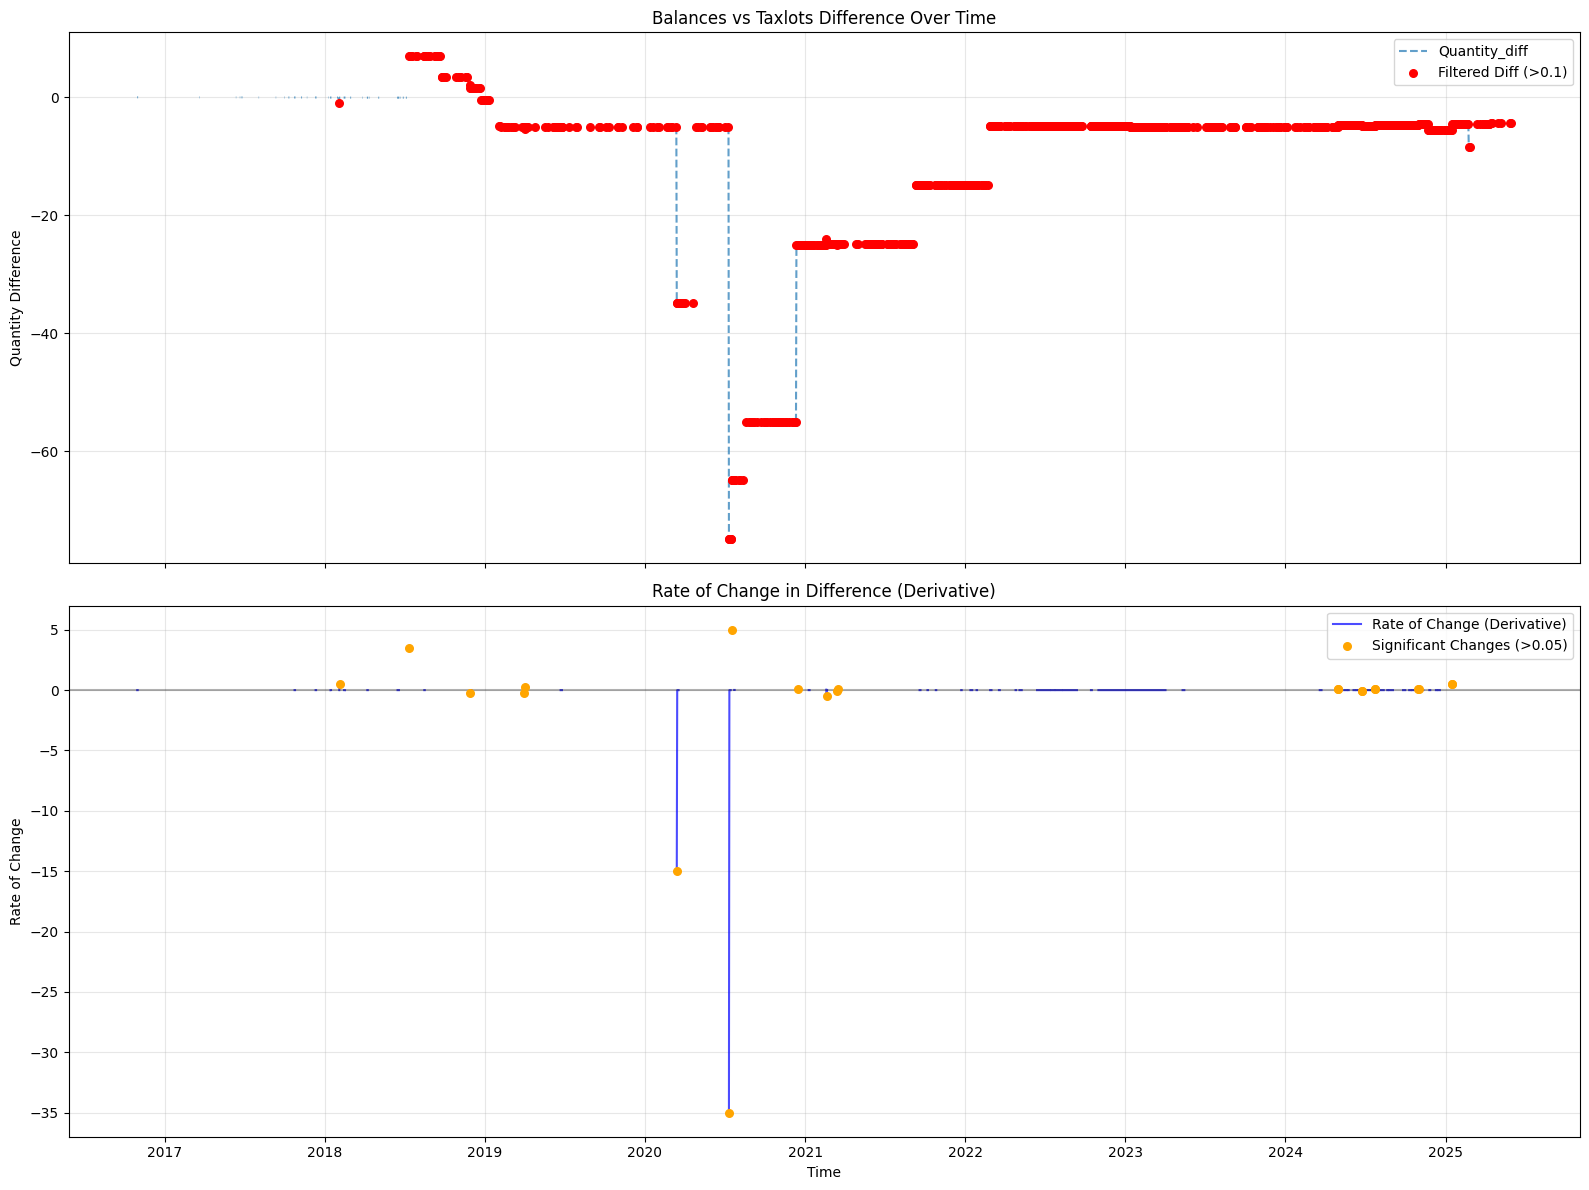

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
balances_df = pd.read_csv('../total_quantity_history_balances.csv')
taxlots_df = pd.read_csv('../total_quantity_history_taxlots.csv')

# Ensure the time column is in datetime format
balances_df['Time'] = pd.to_datetime(balances_df['Time'])
taxlots_df['Time'] = pd.to_datetime(taxlots_df['Time'])
balances_df_monthly = balances_df.resample('D', on='Time').last()
taxlots_df_monthly = taxlots_df.resample('D', on='Time').last()

# Merge the two DataFrames on the 'Time' column
merged_df = pd.merge(balances_df_monthly, taxlots_df_monthly, on='Time', suffixes=('_balances', '_taxlots'))

# Add a new column for the difference between the 'Quantity' columns
merged_df['Quantity_diff'] = merged_df['Quantity_balances'] - merged_df['Quantity_taxlots']

# Calculate the derivative (rate of change) of the difference
merged_df['Quantity_diff_derivative'] = np.gradient(merged_df['Quantity_diff'])

# Filter for significant differences and significant changes
filtered_df = merged_df[merged_df['Quantity_diff'].abs() > 0.1]
change_points_df = merged_df[merged_df['Quantity_diff_derivative'].abs() > 0.05]  # Significant rate of change

display("Filtered differences (>0.1):")
display(filtered_df[['Quantity_diff', 'Quantity_diff_derivative']])

display("Significant change points (derivative >0.05):")
display(change_points_df[['Quantity_diff', 'Quantity_diff_derivative']])

# Create subplots for better visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Top plot: Original difference with filtered points
ax1.plot(merged_df.index, merged_df['Quantity_diff'], label='Quantity_diff', linestyle='--', alpha=0.7)
ax1.scatter(filtered_df.index, filtered_df['Quantity_diff'], color='red', label='Filtered Diff (>0.1)', s=30, zorder=5)
ax1.set_ylabel('Quantity Difference')
ax1.set_title('Balances vs Taxlots Difference Over Time')
ax1.legend()
ax1.grid(True, which='major', linestyle='-', alpha=0.3)
ax1.grid(True, which='minor', linestyle=':', alpha=0.2)

# Bottom plot: Derivative with change points
ax2.plot(merged_df.index, merged_df['Quantity_diff_derivative'], label='Rate of Change (Derivative)', color='blue', alpha=0.7)
ax2.scatter(change_points_df.index, change_points_df['Quantity_diff_derivative'], color='orange', label='Significant Changes (>0.05)', s=30, zorder=5)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)  # Zero line for reference
ax2.set_xlabel('Time')
ax2.set_ylabel('Rate of Change')
ax2.set_title('Rate of Change in Difference (Derivative)')
ax2.legend()
ax2.grid(True, which='major', linestyle='-', alpha=0.3)
ax2.grid(True, which='minor', linestyle=':', alpha=0.2)

plt.tight_layout()
plt.show()